<a href="https://colab.research.google.com/github/Averkios1/End-to-End-Detection-Using-Yolov5-/blob/main/train_yolov5_object_detection_on_custom_%5BRUST7%5Ddata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLOv5 on Custom Objects

> **⚠️ Note:** This notebook has been updated since its creation. You may find it slightly different to the version shown in the accompanying [YouTube video](https://www.youtube.com/watch?v=x0ThXHbtqCQ) or [blog post](https://blog.roboflow.com/how-to-train-yolov5-on-a-custom-dataset/).

YOLOv5 is a popular version of the YOLO (You Only Look Once) object detection and image segmentation model, released on November 22, 2022 by Ultralytics. The YOLOv5 model is designed to be fast, accurate, and easy to use, making it an excellent choice for a wide range of object detection and image segmentation tasks. It can be trained on large datasets and is capable of running on a variety of hardware platforms, from CPUs to GPUs.

## Disclaimer

If you notice that our notebook behaves incorrectly - especially if you experience errors that prevent you from going through the tutorial - don't hesitate! Let us know and open an [issue](https://github.com/roboflow/notebooks/issues) on the Roboflow Notebooks repository.

## Accompanying Blog Post

We recommend that you follow along in this notebook while reading the blog post on [how to train YOLOv5](https://blog.roboflow.ai/how-to-train-yolov5-on-a-custom-dataset/), concurrently.

## Steps Covered in this Tutorial

In this tutorial, we will walk through the steps required to train YOLOv5 on your custom objects. We use the [Cash Counter](https://universe.roboflow.com/alex-hyams-cosqx/cash-counter/dataset/11) dataset, which is open source and free to use. You can also use this notebook on your own data.

To train our detector we take the following steps:

- Before you start
- Install YOLOv5
- Roboflow Universe
- Prepare a Custom Dataset
- Download custom YOLOv5 object detection data
- Train Custom YOLOv5 Detector
- Evaluate Custom YOLOv5 Detector Performance
- Run Inference With Trained Weights
- Deploy Model on Roboflow
- Deploy Your Model to the Edge

Let's get started!

## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
%pwd


'/content'

In [2]:
!nvidia-smi

Mon Oct 27 23:08:09 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   39C    P8             11W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os
HOME = os.getcwd()
print(HOME)

/content


# Install YOLOv5


In [4]:
# clone YOLOv5 repository
%cd /content
!git clone https://github.com/ultralytics/yolov5

/content
Cloning into 'yolov5'...
remote: Enumerating objects: 17639, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 17639 (delta 11), reused 8 (delta 8), pack-reused 17601 (from 3)
Receiving objects: 100% (17639/17639), 16.96 MiB | 22.85 MiB/s, done.
Resolving deltas: 100% (11987/11987), done.


In [5]:
%cd yolov5

/content/yolov5


In [6]:
# install dependencies as necessary
#!pip install -r requirements.txt
#
!pip install -qr requirements.txt
!pip uninstall wandb -qy  # deprecated dependency
import torch

from IPython.display import Image, clear_output  # to display images
#%pip install -r requirements.txt
#!pip install -qr requirements.txt
# clear_output()
print('Setup complete. Using torch %s %s' % (torch.__version__, torch.cuda.get_device_properties(0) if torch.cuda.is_available() else 'CPU'))

#from models.common import DetectMultiBackend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 33.3 MB/s eta 0:00:00
Setup complete. Using torch 2.8.0+cu126 _CudaDeviceProperties(name='NVIDIA L4', major=8, minor=9, total_memory=22692MB, multi_processor_count=58, uuid=921928e8-84bc-6091-1720-e07f434a059a, pci_bus_id=0, pci_device_id=3, pci_domain_id=0, L2_cache_size=48MB)


## Roboflow Universe

Need data for your project? Before spending time on annotating, check out Roboflow Universe, a repository of more than 200,000 open-source datasets that you can use in your projects. You'll find datasets containing everything from annotated cracks in concrete to plant images with disease annotations.


[![Roboflow Universe](https://media.roboflow.com/notebooks/template/uni-banner-frame.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672878480290)](https://universe.roboflow.com/)

## Preparing a custom dataset

Building a custom dataset can be a painful process. It might take dozens or even hundreds of hours to collect images, label them, and export them in the proper format. Fortunately, Roboflow makes this process as straightforward and fast as possible. Let me show you how!

### Step 1: Creating project

Before you start, you need to create a Roboflow [account](https://app.roboflow.com/login). Once you do that, you can create a new project in the Roboflow [dashboard](https://app.roboflow.com/). Keep in mind to choose the right project type. In our case, Object Detection.

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/creating-project.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1672929799852"
  >
</div>

### Step 2: Uploading images

Next, add the data to your newly created project. You can do it via API or through our [web interface](https://docs.roboflow.com/adding-data/object-detection).

If you drag and drop a directory with a dataset in a supported format, the Roboflow dashboard will automatically read the images and annotations together.

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/uploading-images.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1672929808290"
  >
</div>

### Step 3: Labeling

If you only have images, you can label them in [Roboflow Annotate](https://docs.roboflow.com/annotate).

<div align="center">
  <img
    width="640"
    src="https://user-images.githubusercontent.com/26109316/210901980-04861efd-dfc0-4a01-9373-13a36b5e1df4.gif"
  >
</div>

### Step 4: Generate new dataset version

Now that we have our images and annotations added, we can Generate a Dataset Version. When Generating a Version, you may elect to add preprocessing and augmentations. This step is completely optional, however, it can allow you to significantly improve the robustness of your model.

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/generate-new-version.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1673003597834"
  >
</div>

### Step 5: Exporting dataset

Once the dataset version is generated, we have a hosted dataset we can load directly into our notebook for easy training. Click `Export` and select the `YOLO v5 PyTorch` dataset format.

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/export.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1672943313709"
  >
</div>


## Step 6: Download a Dataset

Run the code below to authenticate with Roboflow and download the dataset. Follow the link to generate an authentication token.

Alternatively, provide an API key like so: `rf = Roboflow(api_key=...)`

> 🟢 **Tip:** The examples below work even if you use our non-custom dataset. However, you won't be able to deploy the model to Roboflow. To do that, create a custom dataset as described above or fork (copy) one into your [workspace](https://app.roboflow.com/) from [Universe](https://universe.roboflow.com/).

In [7]:
#!mkdir {HOME}/datasets
#%cd {HOME}/datasets

In [8]:
#!mkdir {HOME}/datasets
#%cd {HOME}/datasets

%cd /content/yolov5
#!pip install -q roboflow==1.1.48

#import roboflow
#roboflow.login()

#rf = roboflow.Roboflow()
#project = rf.workspace("model-examples").project("cash-counter-p08xm")
#dataset = project.version(3).download("yolov5")



!pip install roboflow

from roboflow import Roboflow
#rf = Roboflow(api_key="BvZh6hkT8RUb5nh3mysx")
#project = rf.workspace("rust-detection").project("rust-detection-38s6e")
#version = project.version(1)
rf = Roboflow(api_key="BvZh6hkT8RUb5nh3mysx")
project = rf.workspace("averkios").project("rust-corrosion-detection")
version = project.version(16)
dataset = version.download("yolov5")
#dataset = project.version(11).download(
#    "yolov5",   # format: "coco", "voc", "yolov5", etc.
#    filters={"tags": ["HO"]}
#)

/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 151.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Rust-Corrosion-Detection-16 in yolov5pytorch:: 100%|██████████| 16720/16720 [00:02<00:00, 6969.86it/s] 


In [9]:
#!cd /content/yolov5/Rust-Corrosion-Detection-2/train/labels
%cd /content/yolov5


/content/yolov5


In [10]:
#import os
#from google.colab import files

# Specify the directory
#directory_path = '/content/yolov5/Rust-Corrosion-Detection-2/train/labels'

# Get a list of files in the directory
#files_in_directory = os.listdir(directory_path)

# Filter for files that are .txt and start with "frame_"
#files_to_download = [f for f in files_in_directory if f.endswith('.txt') and f.startswith('frame_')]

# Download each selected file
#for file_name in files_to_download:
#    file_path = os.path.join(directory_path, file_name)
#    try:
#        files.download(file_path)
#    except Exception as e:
#        print(f"Error downloading {file_name}: {e}")

In [11]:
import os
#import zipfile
from google.colab import files

# Specify the directory
directory_path_images = '/content/yolov5/Rust-Corrosion-Detection-16/train/images'
files_in_directory_images = os.listdir(directory_path_images)

directory_path_txt = '/content/yolov5/Rust-Corrosion-Detection-16/train/labels'
files_in_directory_txt = os.listdir(directory_path_txt)
#zip_file_name = 'frame_txt.zip'

# Get a list of files in the directory


# Filter for files that are .txt and start with "frame_"
#files_txt_select = [f for f in files_in_directory_txt if f.endswith('.txt') and f.startswith('frame_1')]
import re

files_txt_select = [
    f for f in files_in_directory_txt
    if f.endswith('.txt') and f.startswith('frame') #and
       #int(f.split('_')[1]) >= 7 and int(f.split('_')[1]) <= 16 and int(f.split('_')[1]) != 13 #and int(f.split('_')[1]) != 18 and int(f.split('_')[1]) != 17 and int(f.split('_')[1]) != 19 #and #int(f.split('_')[1]) != 10
       #int(f.split('_')[1]) >= 1014 and int(f.split('_')[1]) <= 1075 and int(f.split('_')[1]) != 13
       #int(f.split('_')[1]) >= 2000 and int(f.split('_')[1]) <= 2008 #
       #int(f.split('_')[1].split('-')[0]) >= 5000 and int(f.split('_')[1].split('-')[0]) <= 5009
]


print(files_txt_select)



#files_jpg_select = [f for f in files_in_directory_images if f.endswith('.jpg') and f.startswith('frame_1')]
#import re

files_jpg_select = [
    f for f in files_in_directory_images
    if f.endswith('.jpg') and f.startswith('frame') #and
       #int(f.split('_')[1]) >= 7 and int(f.split('_')[1]) <= 16 and int(f.split('_')[1]) != 13 #and int(f.split('_')[1]) != 18 and int(f.split('_')[1]) != 17 and int(f.split('_')[1]) != 19 #and #int(f.split('_')[1]) != 10
       #int(f.split('_')[1]) >= 1014 and int(f.split('_')[1]) <= 1075 and int(f.split('_')[1]) != 13
       #int(f.split('_')[1]) >= 2000 and int(f.split('_')[1]) <= 2008 #and int(f.split('_')[1]) != 13
       #int(f.split('_')[1].split('-')[0]) >= 5000 and int(f.split('_')[1].split('-')[0]) <= 5009  #and int(f.split('_')[1]) != 13
]


print(files_jpg_select)

['frame_1065_jpg.rf.f12d8b16f92f6882e973f2434eadcaff.txt', 'frame_7018_jpg.rf.4dff224e56f6a8d9a35591b31b102d31.txt', 'frame_0005_jpg.rf.bfb0c05791dcdd4cd163018f91e427bf.txt', 'frame_0014_jpg.rf.eafce80c8586dc9cf903186dba0c3e65.txt', 'frame_1042_jpg.rf.7a3daf422be2116dd796552873b17fc0.txt', 'frame_1054_jpg.rf.5f2a296e42a2d4bf8e91243c884b6110.txt', 'frame_7002_jpg.rf.e89374d38a771c37905837dc1746806c.txt', 'frame_7040_jpg.rf.d5f6179416f2baedc7ddc03a0e7394fb.txt', 'frame_1035_jpg.rf.b2ac4df28298dcd9d5573c08ab273f9f.txt', 'frame_1014_jpg.rf.97f6a5ac455d216f8d7972cbd4708f0c.txt', 'frame_1033_jpg.rf.7f13d3d61a663158e1930f1f5b6319ba.txt', 'frame_1070_jpg.rf.837155542a4557169d59662968983162.txt', 'frame_4016_jpg.rf.3051764ae9cbc490c33f659df05ed6f4.txt', 'frame_1005_jpg.rf.489b420ffa50fa4db0b6b36095d3baf5.txt', 'frame_7036_jpg.rf.6b4973ebca628102355c8bc0602ec608.txt', 'frame_7025_jpg.rf.7aa4a94a05e0d1ad9264e4f28d4041c9.txt', 'frame_4008_jpg.rf.e486b06264ac36e1d5267f22f9922958.txt', 'frame_1069_j

In [12]:
import os
import shutil
import yaml

# === CONFIGURATION ===
# Path to the dataset containing all images and labels
base_dir = "/content/yolov5/Rust-Corrosion-Detection-16/train/"  # <- CHANGE THIS
images_dir = os.path.join(base_dir, "images")
labels_dir = os.path.join(base_dir, "labels")

# Output directory for the custom validation subset
output_base = "/content/yolov5/custom_eval_set_600"
output_img_dir = os.path.join(output_base, "images")
output_lbl_dir = os.path.join(output_base, "labels")
output_yaml_path = os.path.join(output_base, "data.yaml")

# List of image filenames to extract (can be read from a .txt file if preferred)
selected_filenames = files_jpg_select    #[
    #"img001.jpg",
    #"img045.jpg",
    #"img103.jpg",
    # Add more here
#]

# Class metadata (customize as needed)
nc = 4
names = ["corrosion", "moderate corrosion", "rust", "severe corrosion"] #["cat", "dog"]  # Replace with your actual class names

# === CREATE OUTPUT FOLDERS ===
os.makedirs(output_img_dir, exist_ok=True)
os.makedirs(output_lbl_dir, exist_ok=True)

# === PROCESS FILES ===
for img_name in selected_filenames:
    lbl_name = img_name.replace(".jpg", ".txt")  # Assumes .jpg image and .txt label

    src_img = os.path.join(images_dir, img_name)
    src_lbl = os.path.join(labels_dir, lbl_name)
    dst_img = os.path.join(output_img_dir, img_name)
    dst_lbl = os.path.join(output_lbl_dir, lbl_name)

    if os.path.exists(src_img) and os.path.exists(src_lbl):
        shutil.copy2(src_img, dst_img)
        shutil.copy2(src_lbl, dst_lbl)
        print(f"✔ Copied: {img_name}")
    else:
        print(f"⚠️ Skipped (missing): {img_name}")

# === CREATE data.yaml ===
data_yaml = {
    "train": os.path.abspath(output_img_dir),#"dummy",  # Not used
    "val": os.path.abspath(output_img_dir),
    "test": os.path.abspath(output_img_dir),
    "nc": nc,
    "names": names
}

with open(output_yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

print(f"\n✅ Done. Validation set created at: {output_base}")
print(f"📝 data.yaml saved to: {output_yaml_path}")


✔ Copied: frame_1029_jpg.rf.6a1381bae65fa4b07ea787ad6571377e.jpg
✔ Copied: frame_1011_jpg.rf.fedbbcc3ea5ea5a5fa96bbf920368705.jpg
✔ Copied: frame_7004_jpg.rf.29df0b9fa48d0c54386b31909342cfde.jpg
✔ Copied: frame_0004_jpg.rf.823cc3a6f825189dd95b03c4e8408e50.jpg
✔ Copied: frame_7034_jpg.rf.a7efb450460272f90950029f71bd7c1e.jpg
✔ Copied: frame_4008_jpg.rf.e486b06264ac36e1d5267f22f9922958.jpg
✔ Copied: frame_7033_jpg.rf.1b959367658cb652ca574547ce1880e6.jpg
✔ Copied: frame_7046_jpg.rf.fa0095e3b1b8e80ca050e5e5aaaa3abf.jpg
✔ Copied: frame_0018_jpg.rf.e49959b75ee66d8531159df94a041947.jpg
✔ Copied: frame_1009_jpg.rf.8bebf95e3ddcc43604083c984787304a.jpg
✔ Copied: frame_4007_jpg.rf.8815ccdcc9dc26f0f03a3e09245c0009.jpg
✔ Copied: frame_1063_jpg.rf.d20b5295544c3f23b4e4c5e371ee7a2f.jpg
✔ Copied: frame_0011_jpg.rf.8f3187a74f67780bb787b9389f96ea42.jpg
✔ Copied: frame_5008_jpg.rf.b0cf1c4847fae8b2b68c2a6f0d14ed38.jpg
✔ Copied: frame_5019_jpg.rf.438446ab12a552092f5991ee309e8c86.jpg
✔ Copied: frame_7039_jpg.

In [ ]:
#NO
import os
import zipfile
from google.colab import files

# Specify the directory
directory_path = '/content/yolov5/Rust-Corrosion-Detection-2/train/labels'
zip_file_name = 'frame_txt.zip'

# Get a list of files in the directory
files_in_directory = os.listdir(directory_path)

# Filter for files that are .txt and start with "frame_"
files_to_zip = [f for f in files_in_directory if f.endswith('.txt') and f.startswith('frame_')]

# Create the zip file
with zipfile.ZipFile(zip_file_name, 'w') as zipf:
    for file_name in files_to_zip:
        file_path = os.path.join(directory_path, file_name)
        zipf.write(file_path, os.path.basename(file_path)) # Add file to zip with its base name

# Download the zip file
try:
    files.download(zip_file_name)
except Exception as e:
    print(f"Error downloading {zip_file_name}: {e}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/yolov5/Rust-Corrosion-Detection-2/train/labels'

In [ ]:
#NO
import os
#import zipfile
from google.colab import files

# Specify the directory
directory_path = '/content/yolov5/Rust-Corrosion-Detection-4/train/labels'
zip_file_name = 'frame_txt.zip'

# Get a list of files in the directory
files_in_directory = os.listdir(directory_path)

# Filter for files that are .txt and start with "frame_"
files_to_zip = [f for f in files_in_directory if f.endswith('.txt') and f.startswith('frame_')]
print(files_to_zip)


FileNotFoundError: [Errno 2] No such file or directory: '/content/yolov5/Rust-Corrosion-Detection-4/train/labels'

# Train Custom YOLOv5 Detector

### Next, we'll fire off training!


Here, we are able to pass a number of arguments:
- **img:** define input image size
- **batch:** determine batch size
- **epochs:** define the number of training epochs. (Note: often, 3000+ are common here!)
- **data:** set the path to our yaml file
- **cfg:** specify our model configuration
- **weights:** specify a custom path to weights. (Note: you can download weights from the Ultralytics Google Drive [folder](https://drive.google.com/open?id=1Drs_Aiu7xx6S-ix95f9kNsA6ueKRpN2J))
- **name:** result names
- **cache:** cache images for faster training

In [13]:
# train yolov5s on custom data for 25 epochs
# time its performance #{dataset.location}/data.yaml
%%time
%cd /content/yolov5/
!python train.py \
  --img 416 \
  --batch 16 \
  --epochs 45 \
  --data {dataset.location}/data.yaml \
  --weights yolov5s.pt \
  --name yolov5s_results5  \
  --cache

/content/yolov5
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
2025-10-27 23:12:03.650585: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761606723.671936    1948 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761606723.678349    1948 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761606723.694619    1948 computation_placer.cc:177] computation placer already registered. Please

In [14]:
# train yolov5s on custom data for 25 epochs
# time its performance #{dataset.location}/data.yaml
%%time
%cd /content/yolov5/
!python train.py \
  --img 416 \
  --batch 16 \
  --epochs 45 \
  --data /content/yolov5/custom_eval_set_600/data.yaml \
  --weights yolov5s.pt \
  --name yolov5s_results86  \
  --cache

/content/yolov5
2025-10-27 23:14:56.392170: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761606896.413406    2886 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761606896.419921    2886 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761606896.436559    2886 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761606896.436593    2886 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761606896.436596    2886 computation_placer.cc:177] comput

# Evaluate Custom YOLOv5 Detector Performance

You can view the training graphs associated with a training job in the `/content/yolov5/runs/train/yolov5s_results/results.png` folder.

Training losses and performance metrics are also saved to Tensorboard and also to a logfile defined above with the **--name** flag when we train. In our case, we named this `yolov5s_results`.

Note from Glenn: Partially completed `results.txt` files can be plotted with `from utils.utils import plot_results; plot_results()`.

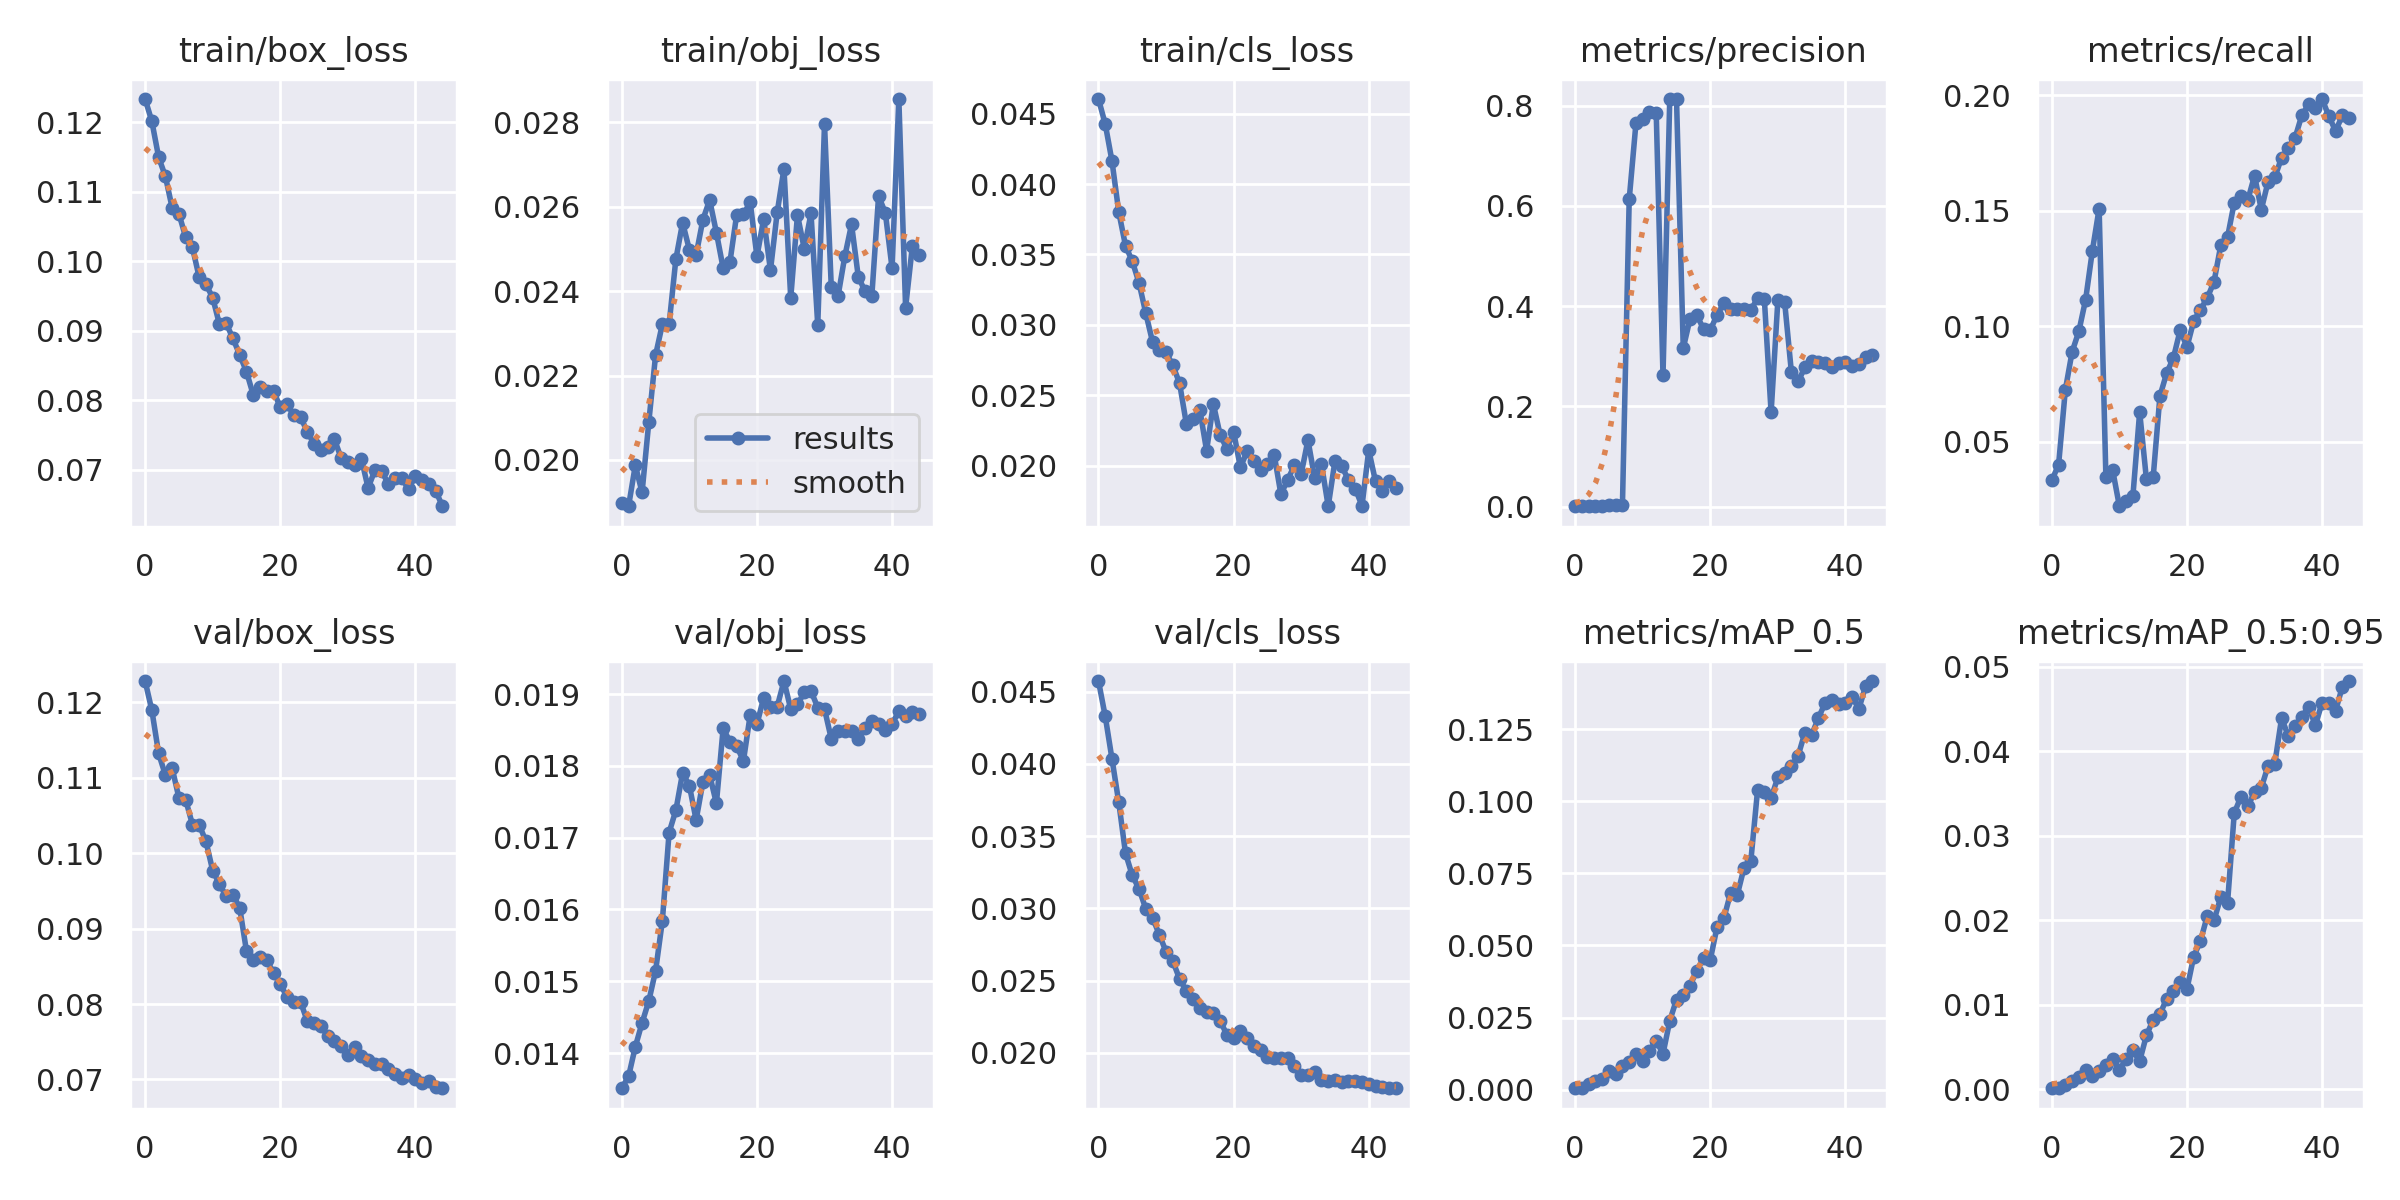

In [ ]:
from utils.plots import plot_results  # plot results.txt as results.png
Image(filename='/content/yolov5/runs/train/yolov5s_results77/results.png', width=1000)

### Curious? Visualize Our Training Data with Labels

After training starts, view `train*.jpg` images to see training images, labels and augmentation effects.

Note a mosaic dataloader is used for training (shown below), a new dataloading concept developed by Glenn Jocher and first featured in [YOLOv4](https://arxiv.org/abs/2004.10934).

In [15]:
Image(filename='/content/yolov5/runs/train/yolov5s_results77/val_batch0_labels.jpg', width=900)

FileNotFoundError: [Errno 2] No such file or directory: '/content/yolov5/runs/train/yolov5s_results77/val_batch0_labels.jpg'

In [17]:
# print out an augmented training example
print("GROUND TRUTH AUGMENTED TRAINING DATA:")
Image(filename='/content/yolov5/runs/train/yolov5s_results77/train_batch0.jpg', width=900)

GROUND TRUTH AUGMENTED TRAINING DATA:


FileNotFoundError: [Errno 2] No such file or directory: '/content/yolov5/runs/train/yolov5s_results77/train_batch0.jpg'

# Run Inference With Trained Weights

Next, we can run inference with a pretrained checkpoint on all images in the `test/images` folder to understand how our model performs on our test set.

In [18]:
%pwd

'/content/yolov5'

In [19]:
# trained weights are saved by default in our weights folder
%ls runs/

train/


In [ ]:
%ls runs/train/yolov5s_results77/weights

best.pt  last.pt


In [ ]:
%cd /content/yolov5/
!python detect.py --weights runs/train/yolov5s_results5/weights/best.pt --img 416 --conf 0.25 --source /content/yolov5/custom_eval_set_200/images

/content/yolov5
detect: weights=['runs/train/yolov5s_results5/weights/best.pt'], source=/content/yolov5/custom_eval_set_200/images, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-432-g725b922e Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)

Fusing layers... 
Model summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
image 1/183 /content/yolov5/custom_eval_set_200/images/frame_0001_jpg.rf.3f33b0476093443ec357fe866392f5e0.jpg: 416x416 8 moderate corrosions, 6.1ms
image 2/183 /content/yolov5/custom_eval_set_200/images/frame_0002_jpg.rf.335adec2adce64041f2f238ce6cc6432.jpg: 41

In [ ]:
%cd /content/yolov5/
!python detect.py --weights runs/train/yolov5s_results/weights/best.pt --img 416 --conf 0.25 --source /content/yolov5/custom_eval_set_200/images

/content/yolov5
detect: weights=['runs/train/yolov5s_results/weights/best.pt'], source=/content/yolov5/custom_eval_set_200/images, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-432-g725b922e Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)

Fusing layers... 
Model summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
image 1/183 /content/yolov5/custom_eval_set_200/images/frame_0001_jpg.rf.0112149f4615c7b2418c1f6149db1d7b.jpg: 416x416 5 moderate corrosions, 6.2ms
image 2/183 /content/yolov5/custom_eval_set_200/images/frame_0002_jpg.rf.ddb02eb572ea400f13e98413fc95e1da.jpg: 416

In [20]:
%cd /content/yolov5/
!python detect.py --weights runs/train/yolov5s_results86/weights/best.pt --img 416 --conf 0.35 --source /content/yolov5/custom_eval_set_600/images

/content/yolov5
detect: weights=['runs/train/yolov5s_results86/weights/best.pt'], source=/content/yolov5/custom_eval_set_600/images, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.35, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-443-gbe00b6b6 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)

Fusing layers... 
Model summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
image 1/183 /content/yolov5/custom_eval_set_600/images/frame_0001_jpg.rf.c6ee26b95089c54dd3e1dc2581b96470.jpg: 416x416 3 moderate corrosions, 6.0ms
image 2/183 /content/yolov5/custom_eval_set_600/images/frame_0002_jpg.rf.d6d4b0a69dd68df1af3120538d60c41e.jpg: 4

In [ ]:
!python val.py --weights /content/yolov5/runs/train/yolov5s_results5/weights/best.pt --data /content/yolov5/custom_eval_set_200/data.yaml --img 640 --save-txt --save-conf --save-hybrid --conf-thres 0.25  #--save-json

val: data=/content/yolov5/custom_eval_set_200/data.yaml, weights=['/content/yolov5/runs/train/yolov5s_results5/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.25, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=True, save_hybrid=True, save_conf=True, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
WARNING ⚠️ confidence threshold 0.25 > 0.001 produces invalid results
WARNING ⚠️ --save-hybrid will return high mAP from hybrid labels, not from predictions alone
YOLOv5 🚀 v7.0-432-g725b922e Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)

Fusing layers... 
Model summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
val: Scanning /content/yolov5/custom_eval_set_200/labels... 183 images, 0 backgrounds, 0 corrupt: 100% 183/183 [00:00<00:00, 6929.54it/s]
val: New cache created: /content/yolov5/custom_eval_set_200/labels.cache
                 Class     Images 

In [21]:
!python val.py --weights /content/yolov5/runs/train/yolov5s_results86/weights/best.pt --data /content/yolov5/custom_eval_set_600/data.yaml --img 640 --save-txt --save-conf --save-hybrid --conf-thres 0.35  #--save-json

val: data=/content/yolov5/custom_eval_set_600/data.yaml, weights=['/content/yolov5/runs/train/yolov5s_results86/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.35, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=True, save_hybrid=True, save_conf=True, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
WARNING ⚠️ confidence threshold 0.35 > 0.001 produces invalid results
WARNING ⚠️ --save-hybrid will return high mAP from hybrid labels, not from predictions alone
YOLOv5 🚀 v7.0-443-gbe00b6b6 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)

Fusing layers... 
Model summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
val: Scanning /content/yolov5/custom_eval_set_600/labels.cache... 183 images, 0 backgrounds, 0 corrupt: 100% 183/183 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 6/6 [00:04<00:0

In [ ]:
%cd /content/yolov5/
!python detect.py --weights runs/train/yolov5s_results/weights/best.pt --img 416 --conf 0.35 --source {dataset.location}/test/images/

/content/yolov5
detect: weights=['runs/train/yolov5s_results/weights/best.pt'], source=/content/yolov5/Rust-Corrosion-Detection-11/test/images/, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.35, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-430-g459d8bf0 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)

Fusing layers... 
Model summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
image 1/232 /content/yolov5/Rust-Corrosion-Detection-11/test/images/0_original_corrosion_detected-1-_png_jpg.rf.7f11624b3c39a6409ad8778594c04967.jpg: 416x416 3 moderate corrosions, 1 severe corrosion, 6.5ms
image 2/232 /content/yolov5/Rust-Corrosio

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pwd

/content/yolov5


In [ ]:
!cp runs/train/yolov5s_results86/weights/best.pt /content/drive/MyDrive/Colab_Notebooks_Boxing_weights/Rust_24_9_25_v16_with_183images_45epochs/yolov5/best.pt

In [ ]:
!cp runs/train/yolov5s_results86/weights/last.pt /content/drive/MyDrive/Colab_Notebooks_Boxing_weights/Rust_24_9_25_v16_with_183images_45epochs/yolov5/last.pt

In [ ]:
!cp runs/train/yolov5s_results/weights/best.pt /content/drive/MyDrive/Colab_Notebooks_Boxing_weights/Rust_15_9_25_v11_45epochs/yolov5/best.pt

cp: cannot stat 'runs/train/yolov5s_results/weights/best.pt': No such file or directory


In [ ]:
!cp runs/train/yolov5s_results/weights/best.pt /content/drive/MyDrive/Colab_Notebooks_Boxing_weights/Rust_30_7_25_v10_45epochs/yolov5/best.pt

In [ ]:
!cp runs/train/yolov5s_results/weights/last.pt /content/drive/MyDrive/Colab_Notebooks_Boxing_weights/Rust_30_7_25_v10_45epochs/yolov5/last.pt

In [ ]:
!ls runs/train/yolov5s_results/weights/

best.pt  last.pt


In [ ]:
#Step 2: Upload your MP4 video from local drive
%cd {dataset.location}
from google.colab import files
uploaded = files.upload()  # upload input.mp4

/content/yolov5/Rust-Corrosion-Detection-11


Saving mast_video_reduced.mp4 to mast_video_reduced.mp4


In [ ]:
%cd ..

/content/yolov5


In [ ]:
!pwd

/content/yolov5


In [ ]:
%cd /content/yolov5/

/content/yolov5


In [ ]:
!python detect.py --weights runs/train/yolov5s_results/weights/best.pt --img 416 --conf 0.35 --source {dataset.location}/final_combined_video4.mp4

detect: weights=['runs/train/yolov5s_results/weights/best.pt'], source=/content/yolov5/Rust-Corrosion-Detection-11/final_combined_video4.mp4, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.35, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-430-g459d8bf0 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)

Fusing layers... 
Model summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
video 1/1 (1/556) /content/yolov5/Rust-Corrosion-Detection-11/final_combined_video4.mp4: 256x416 2 moderate corrosions, 49.5ms
video 1/1 (2/556) /content/yolov5/Rust-Corrosion-Detection-11/final_combined_video4.mp4: 256x416 2 moderate corrosions, 9.4m

In [ ]:
!python detect.py --weights runs/train/yolov5s_results/weights/best.pt --img 416 --conf 0.35 --source {dataset.location}/mast_video_reduced.mp4

detect: weights=['runs/train/yolov5s_results/weights/best.pt'], source=/content/yolov5/Rust-Corrosion-Detection-11/mast_video_reduced.mp4, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.35, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-430-g459d8bf0 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)

Fusing layers... 
Model summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
video 1/1 (1/565) /content/yolov5/Rust-Corrosion-Detection-11/mast_video_reduced.mp4: 256x416 4 moderate corrosions, 48.4ms
video 1/1 (2/565) /content/yolov5/Rust-Corrosion-Detection-11/mast_video_reduced.mp4: 256x416 6 moderate corrosions, 6.7ms
video 1

In [ ]:
files.download('/content/yolov5/runs/detect/exp2/mast_video_reduced.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Install dependencies (if needed)
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install -q opencv-python-headless scikit-learn


In [ ]:
import os
# === CONFIGURATION ===
yolov5_path = '/content/yolov5'  # path to your cloned yolov5 repo
weights_path = '/content/yolov5/runs/train/yolov5s_results2/weights/best.pt'
video_path = '/content/yolov5/Rust-Corrosion-Detection-3/mast_video_reduced.mp4'
ground_truth_dir = '/content/yolov5/Rust-Corrosion-Detection-3/train/labels'  # Must contain frame_1.txt, frame_2.txt etc.
IOU_THRESH = 0.2
CONF_THRESH = 0.2


# Output files
detection_log_path = '/content/detection_log.txt'
csv_metrics_path = '/content/detection_metrics.csv'
annotated_video_path = '/content/annotated_output.mp4'


In [ ]:
import cv2
import torch
import os
import re
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.metrics import average_precision_score



In [ ]:
# 📦 Load model
model = torch.hub.load(yolov5_path, 'custom', path=weights_path, source='local', force_reload=True)
model.to('cpu')
model.eval()

#class_names = ['corrosion', 'moderate corrosion', 'rust', 'severe corrosion']
#num_classes = len(class_names)

class_names = model.names
print(class_names)


YOLOv5 🚀 v7.0-421-g79c4c31d Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)

Fusing layers... 
Model summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 


{0: 'corrosion', 1: 'moderate corrosion', 2: 'rust', 3: 'severe corrosion'}


In [ ]:
# ✅ Step 5: Helper functions
#class_names = ['corrosion', 'moderate corrosion', 'rust', 'severe corrosion']
#class_names = model.names
#print(class_names)

# 🔁 Utility functions
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

def yolo_to_bbox(xc, yc, w, h, fw, fh):
    xmin = int((xc - w / 2) * fw)
    ymin = int((yc - h / 2) * fh)
    xmax = int((xc + w / 2) * fw)
    ymax = int((yc + h / 2) * fh)
    return [xmin, ymin, xmax, ymax]

def load_ground_truth(frame_number, gt_dir, fw, fh):
    pattern = re.compile(rf'^frame_{frame_number:04d}_jpg\.rf\..+\.txt$')
    boxes = []
    for fname in os.listdir(gt_dir):
        if pattern.match(fname):
            file_path = os.path.join(gt_dir, fname)
            with open(file_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls = int(parts[0])
                        xc, yc, w, h = map(float, parts[1:])
                        box = yolo_to_bbox(xc, yc, w, h, fw, fh)
                        boxes.append((cls, box))
            print(f"✅ Loaded {len(boxes)} GT boxes from: {file_path}")
            break
    return boxes


In [ ]:
# ✅ Step 4: Load only annotated frames
#annotated_files = os.listdir(ground_truth_dir)
#annotated_frame_numbers = sorted([
#    int(match.group(1))
#    for f in annotated_files
#    for match in [re.search(r'frame_(\d{4})', f)]
#    if match
#])
#print('Annotated frames:', annotated_frame_numbers)

# 🧩 Annotated frame IDs
##annotated_files = [f for f in os.listdir(ground_truth_dir) if f.endswith('.txt')]
##annotated_frame_numbers = sorted([
##    int(m.group(1)) for f in annotated_files
##    for m in [re.search(r'frame_(\d{4})', f)] if m
##])

# 🗂️ Extract frame numbers from annotation files
annotated_files = sorted([
    f for f in os.listdir(ground_truth_dir) if f.startswith("frame_") and f.endswith(".txt")
])
annotated_frame_numbers = sorted([
    int(f.split('_')[1]) for f in annotated_files
])

print(f"📸 Found {len(annotated_frame_numbers)} annotated frames.")
print('Annotated frames:', annotated_frame_numbers)

📸 Found 17 annotated frames.
Annotated frames: [1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19]


In [ ]:
cap = cv2.VideoCapture(video_path)
fw = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
fh = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = 1  # force output video to 1 FPS

class_stats = defaultdict(lambda: {"TP": 0, "FP": 0, "FN": 0})
all_predictions = defaultdict(list)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(annotated_video_path, fourcc, fps, (fw, fh))

with open(detection_log_path, 'w') as log_file:
    for frame_id in annotated_frame_numbers:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id - 1)
        ret, frame = cap.read()
        if not ret:
            print(f"⚠️ Frame {frame_id} failed to load.")
            continue

        print(f"\n▶ Frame {frame_id}")
        gt_boxes = load_ground_truth(frame_id, ground_truth_dir, fw, fh)
        print("  GT Boxes:", gt_boxes)
        gt_matched = [False] * len(gt_boxes)

        results = model(frame)
        preds = results.pandas().xyxy[0]
        preds = preds[preds['confidence'] >= CONF_THRESH]

        if preds.empty:
            print("⚠️ No predictions.")
        if not gt_boxes:
            print("⚠️ No ground truths.")

        for _, row in preds.iterrows():
            pred_box = [int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax'])]
            pred_cls = int(row['class'])
            conf = float(row['confidence'])
            log_file.write(f"  Class: {class_names[pred_cls]}, Conf: {conf:.2f}, BBox: {pred_box}\n")
            print(f"🟥 Prediction → {class_names[pred_cls]} @ {conf:.2f}: {pred_box}")

            best_iou, best_gt_idx = 0, -1
            for i, (gt_cls, gt_box) in enumerate(gt_boxes):
                iou = compute_iou(pred_box, gt_box)
                print(f"    📏 IOU with GT ({class_names[gt_cls]}): {iou:.2f}")
                if pred_cls == gt_cls and not gt_matched[i] and iou > best_iou:
                    best_iou, best_gt_idx = iou, i

            if best_iou >= IOU_THRESH:
                class_stats[pred_cls]["TP"] += 1
                gt_matched[best_gt_idx] = True
                all_predictions[pred_cls].append((conf, 1))
            else:
                class_stats[pred_cls]["FP"] += 1
                all_predictions[pred_cls].append((conf, 0))

            cv2.rectangle(frame, (pred_box[0], pred_box[1]), (pred_box[2], pred_box[3]), (255, 0, 0), 2)

        for i, matched in enumerate(gt_matched):
            if not matched:
                gt_cls = gt_boxes[i][0]
                class_stats[gt_cls]["FN"] += 1

        out.write(frame)

cap.release()
out.release()


▶ Frame 1
✅ Loaded 1 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0001_jpg.rf.49d8ef2173fbcb13c56c91704868a367.txt
  GT Boxes: [(1, [1320, 597, 1367, 1080])]
🟥 Prediction → severe corrosion @ 0.37: [496, 9, 588, 561]
    📏 IOU with GT (moderate corrosion): 0.00
🟥 Prediction → severe corrosion @ 0.30: [885, 720, 1064, 860]
    📏 IOU with GT (moderate corrosion): 0.00

▶ Frame 2
✅ Loaded 0 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0002_jpg.rf.d7fa213d6d4b8b4059d9ef5cb100c3fc.txt
  GT Boxes: []
⚠️ No ground truths.
🟥 Prediction → severe corrosion @ 0.33: [496, 9, 588, 558]


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):



▶ Frame 3
✅ Loaded 3 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0003_jpg.rf.f6369a450f775adcf7ebb8347bb40fde.txt
  GT Boxes: [(1, [496, 8, 610, 518]), (1, [1477, 6, 1573, 115]), (1, [1379, 184, 1464, 510])]
🟥 Prediction → severe corrosion @ 0.36: [883, 721, 1067, 858]
    📏 IOU with GT (moderate corrosion): 0.00
    📏 IOU with GT (moderate corrosion): 0.00
    📏 IOU with GT (moderate corrosion): 0.00
🟥 Prediction → severe corrosion @ 0.26: [493, 11, 585, 558]
    📏 IOU with GT (moderate corrosion): 0.71
    📏 IOU with GT (moderate corrosion): 0.00
    📏 IOU with GT (moderate corrosion): 0.00

▶ Frame 4
✅ Loaded 3 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0004_jpg.rf.c05ee0e5f563dfff1a47aba7c3bb8ef2.txt
  GT Boxes: [(1, [519, 8, 599, 363]), (1, [1340, 6, 1527, 388]), (1, [1320, 498, 1362, 1076])]


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


🟥 Prediction → severe corrosion @ 0.37: [497, 11, 583, 558]
    📏 IOU with GT (moderate corrosion): 0.43
    📏 IOU with GT (moderate corrosion): 0.00
    📏 IOU with GT (moderate corrosion): 0.00
🟥 Prediction → severe corrosion @ 0.30: [883, 721, 1065, 851]
    📏 IOU with GT (moderate corrosion): 0.00
    📏 IOU with GT (moderate corrosion): 0.00
    📏 IOU with GT (moderate corrosion): 0.00

▶ Frame 5
✅ Loaded 0 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0005_jpg.rf.01c1b0185765d991adc2e63cfd430748.txt
  GT Boxes: []
⚠️ No ground truths.
🟥 Prediction → severe corrosion @ 0.33: [492, 9, 582, 555]

▶ Frame 6
✅ Loaded 1 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0006_jpg.rf.8541e2bd6e2df6b6451cc67214171689.txt
  GT Boxes: [(1, [578, 784, 627, 1080])]


...

/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):



▶ Frame 15
✅ Loaded 5 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0015_jpg.rf.2e7902d54b4725839190997c9d3edea5.txt
  GT Boxes: [(2, [591, 27, 656, 230]), (2, [585, 0, 651, 305]), (3, [591, 800, 644, 1077]), (3, [599, 12, 654, 407]), (3, [837, 352, 887, 1080])]
⚠️ No predictions.

▶ Frame 17
✅ Loaded 0 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0017_jpg.rf.82a862346eb5c37f7a11fa1a7e1ce30b.txt
  GT Boxes: []


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


⚠️ No ground truths.
🟥 Prediction → severe corrosion @ 0.35: [0, 820, 541, 1078]

▶ Frame 18
✅ Loaded 2 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0018_jpg.rf.a08eb5eb09d48e9da55cf15337d234f0.txt
  GT Boxes: [(3, [616, 210, 661, 1075]), (3, [859, 232, 910, 1060])]
⚠️ No predictions.

▶ Frame 19
✅ Loaded 0 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0019_jpg.rf.868c1f84286c54c946a2cba78173194f.txt
  GT Boxes: []
⚠️ No predictions.
⚠️ No ground truths.


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [ ]:
# 🎥 Evaluation
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise IOError(f"❌ Cannot open video file: {video_path}")

fw = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
fh = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
original_fps = cap.get(cv2.CAP_PROP_FPS)
frame_interval = int(original_fps)  # 1 FPS sampling

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(annotated_video_path, fourcc, 1, (fw, fh))  # Force 1 fps

class_stats = defaultdict(lambda: {"TP": 0, "FP": 0, "FN": 0})
all_predictions = defaultdict(list)

with open(detection_log_path, 'w') as log_file:
    for i, frame_id in enumerate(annotated_frame_numbers):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * frame_interval)
        ret, frame = cap.read()
        if not ret:
            print(f"⚠️ Failed to read frame {i}")
            continue

        print(f"\n▶ Processing video frame {i} vs annotation frame {frame_id}")
        gt_boxes = load_ground_truth(frame_id, ground_truth_dir, fw, fh)
        gt_matched = [False] * len(gt_boxes)

        results = model(frame)
        preds = results.pandas().xyxy[0]
        preds = preds[preds['confidence'] >= CONF_THRESH]

        for _, row in preds.iterrows():
            pred_box = [int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax'])]
            pred_cls = int(row['class'])
            conf = float(row['confidence'])
            log_file.write(f"  Class: {class_names[pred_cls]}, Conf: {conf:.2f}, BBox: {pred_box}\n")

            best_iou, best_gt_idx = 0, -1
            for j, (gt_cls, gt_box) in enumerate(gt_boxes):
                if pred_cls == gt_cls and not gt_matched[j]:
                    iou = compute_iou(pred_box, gt_box)
                    print(f"Prediction box: {pred_box}, GT box: {gt_box}, IOU: {iou:.2f}")
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = j

            if best_iou >= IOU_THRESH:
                class_stats[pred_cls]["TP"] += 1
                gt_matched[best_gt_idx] = True
                all_predictions[pred_cls].append((conf, 1))
            else:
                class_stats[pred_cls]["FP"] += 1
                all_predictions[pred_cls].append((conf, 0))

            cv2.rectangle(frame, (pred_box[0], pred_box[1]), (pred_box[2], pred_box[3]), (255, 0, 0), 2)

        for j, matched in enumerate(gt_matched):
            if not matched:
                gt_cls = gt_boxes[j][0]
                class_stats[gt_cls]["FN"] += 1

        out.write(frame)

cap.release()
out.release()



▶ Processing video frame 0 vs annotation frame 1
✅ Loaded 1 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0001_jpg.rf.49d8ef2173fbcb13c56c91704868a367.txt

▶ Processing video frame 1 vs annotation frame 2
✅ Loaded 0 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0002_jpg.rf.d7fa213d6d4b8b4059d9ef5cb100c3fc.txt


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):



▶ Processing video frame 2 vs annotation frame 3
✅ Loaded 3 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0003_jpg.rf.f6369a450f775adcf7ebb8347bb40fde.txt


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):



▶ Processing video frame 3 vs annotation frame 4
✅ Loaded 3 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0004_jpg.rf.c05ee0e5f563dfff1a47aba7c3bb8ef2.txt


...

/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):



▶ Processing video frame 14 vs annotation frame 17
✅ Loaded 0 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0017_jpg.rf.82a862346eb5c37f7a11fa1a7e1ce30b.txt


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):



▶ Processing video frame 15 vs annotation frame 18
✅ Loaded 2 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0018_jpg.rf.a08eb5eb09d48e9da55cf15337d234f0.txt
Prediction box: [3, 823, 554, 1079], GT box: [616, 210, 661, 1075], IOU: 0.00
Prediction box: [3, 823, 554, 1079], GT box: [859, 232, 910, 1060], IOU: 0.00
Prediction box: [909, 784, 1070, 1062], GT box: [616, 210, 661, 1075], IOU: 0.00
Prediction box: [909, 784, 1070, 1062], GT box: [859, 232, 910, 1060], IOU: 0.00

▶ Processing video frame 16 vs annotation frame 19
✅ Loaded 0 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0019_jpg.rf.868c1f84286c54c946a2cba78173194f.txt


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [ ]:
# 🎥 Evaluation
cap = cv2.VideoCapture(video_path)
fw = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
fh = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

class_stats = defaultdict(lambda: {"TP": 0, "FP": 0, "FN": 0})
all_predictions = defaultdict(list)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(annotated_video_path, fourcc, fps, (fw, fh))

with open(detection_log_path, 'w') as log_file:
#    for frame_id in annotated_frame_numbers:
#        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id - 1)
    for ii, frame_id in enumerate(annotated_frame_numbers):
        cap.set(cv2.CAP_PROP_POS_FRAMES, ii)
        ret, frame = cap.read()
        if not ret:
            print(f"⚠️ Failed to read frame {frame_id}")
            continue

        print(f"\n▶ Processing frame {frame_id}")
        gt_boxes = load_ground_truth(frame_id, ground_truth_dir, fw, fh)
        gt_matched = [False] * len(gt_boxes)

        results = model(frame)
        preds = results.pandas().xyxy[0]
        preds = preds[preds['confidence'] >= CONF_THRESH]

        print("  GT Boxes:", gt_boxes)
        print("  Predictions:")
        for _, row in preds.iterrows():
            pred_box = [int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax'])]
            pred_cls = int(row['class'])
            conf = float(row['confidence'])
            print(f"    → Class: {class_names[pred_cls]}, Conf: {conf:.2f}, Box: {pred_box}")

            log_file.write(f"  Class: {class_names[pred_cls]}, Conf: {conf:.2f}, BBox: {pred_box}\n")

            best_iou, best_gt_idx = 0, -1
            for i, (gt_cls, gt_box) in enumerate(gt_boxes):
                if pred_cls == gt_cls and not gt_matched[i]:
                    iou = compute_iou(pred_box, gt_box)
                    print(f"Prediction box: {pred_box}, GT box: {gt_box}, IOU: {iou:.2f}")
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = i

            if best_iou >= IOU_THRESH:
                class_stats[pred_cls]["TP"] += 1
                gt_matched[best_gt_idx] = True
                all_predictions[pred_cls].append((conf, 1))
            else:
                class_stats[pred_cls]["FP"] += 1
                all_predictions[pred_cls].append((conf, 0))

            cv2.rectangle(frame, (pred_box[0], pred_box[1]), (pred_box[2], pred_box[3]), (255, 0, 0), 2)

        for i, matched in enumerate(gt_matched):
            if not matched:
                gt_cls = gt_boxes[i][0]
                class_stats[gt_cls]["FN"] += 1

        out.write(frame)

cap.release()
out.release()



▶ Processing frame 1
✅ Loaded 1 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0001_jpg.rf.49d8ef2173fbcb13c56c91704868a367.txt
  GT Boxes: [(1, [1320, 597, 1367, 1080])]
  Predictions:
    → Class: severe corrosion, Conf: 0.37, Box: [496, 9, 588, 561]
    → Class: severe corrosion, Conf: 0.30, Box: [885, 720, 1064, 860]

▶ Processing frame 2
✅ Loaded 0 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0002_jpg.rf.d7fa213d6d4b8b4059d9ef5cb100c3fc.txt


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


  GT Boxes: []
  Predictions:
    → Class: severe corrosion, Conf: 0.33, Box: [496, 9, 588, 558]

▶ Processing frame 3
✅ Loaded 3 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0003_jpg.rf.f6369a450f775adcf7ebb8347bb40fde.txt
  GT Boxes: [(1, [496, 8, 610, 518]), (1, [1477, 6, 1573, 115]), (1, [1379, 184, 1464, 510])]
  Predictions:
    → Class: severe corrosion, Conf: 0.36, Box: [883, 721, 1067, 858]
    → Class: severe corrosion, Conf: 0.26, Box: [493, 11, 585, 558]

▶ Processing frame 4


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


✅ Loaded 3 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0004_jpg.rf.c05ee0e5f563dfff1a47aba7c3bb8ef2.txt
  GT Boxes: [(1, [519, 8, 599, 363]), (1, [1340, 6, 1527, 388]), (1, [1320, 498, 1362, 1076])]
  Predictions:
    → Class: severe corrosion, Conf: 0.37, Box: [497, 11, 583, 558]
    → Class: severe corrosion, Conf: 0.30, Box: [883, 721, 1065, 851]

▶ Processing frame 5
✅ Loaded 0 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0005_jpg.rf.01c1b0185765d991adc2e63cfd430748.txt
  GT Boxes: []
  Predictions:
    → Class: severe corrosion, Conf: 0.33, Box: [492, 9, 582, 555]


...

/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


  GT Boxes: [(1, [1343, 4, 1380, 498]), (3, [598, 210, 643, 434]), (3, [597, 842, 641, 1080]), (3, [843, 447, 882, 1080]), (2, [610, 892, 625, 1024]), (2, [614, 234, 630, 376])]
  Predictions:

▶ Processing frame 15
✅ Loaded 5 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0015_jpg.rf.2e7902d54b4725839190997c9d3edea5.txt
  GT Boxes: [(2, [591, 27, 656, 230]), (2, [585, 0, 651, 305]), (3, [591, 800, 644, 1077]), (3, [599, 12, 654, 407]), (3, [837, 352, 887, 1080])]
  Predictions:

▶ Processing frame 17
✅ Loaded 0 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0017_jpg.rf.82a862346eb5c37f7a11fa1a7e1ce30b.txt
  GT Boxes: []
  Predictions:

▶ Processing frame 18
✅ Loaded 2 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0018_jpg.rf.a08eb5eb09d48e9da55cf15337d234f0.txt


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


  GT Boxes: [(3, [616, 210, 661, 1075]), (3, [859, 232, 910, 1060])]
  Predictions:

▶ Processing frame 19
✅ Loaded 0 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0019_jpg.rf.868c1f84286c54c946a2cba78173194f.txt
  GT Boxes: []
  Predictions:
    → Class: severe corrosion, Conf: 0.35, Box: [0, 820, 541, 1078]


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [ ]:
# 📊 Compute metrics
rows = []
ap_scores = []

for cls_id, stats in class_stats.items():
    tp, fp, fn = stats["TP"], stats["FP"], stats["FN"]
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    if cls_id in all_predictions:
        sorted_preds = sorted(all_predictions[cls_id], key=lambda x: -x[0])
        y_true = [p[1] for p in sorted_preds]
        y_scores = [p[0] for p in sorted_preds]
        ap = average_precision_score(y_true, y_scores) if len(set(y_true)) > 1 else 0.0
    else:
        ap = 0.0
    ap_scores.append(ap)

    rows.append({
        "class_id": cls_id,
        "class_name": class_names[cls_id],
        "TP": tp, "FP": fp, "FN": fn,
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "AP": round(ap, 4)
    })

mean_ap = round(np.mean(ap_scores), 4)
rows.append({
    "class_id": "mean", "class_name": "mAP",
    "TP": "", "FP": "", "FN": "",
    "precision": "", "recall": "", "AP": mean_ap
})

df_metrics = pd.DataFrame(rows)
df_metrics.to_csv(csv_metrics_path, index=False)
df_metrics


,class_id,class_name,TP,FP,FN,precision,recall,AP
0,3,severe corrosion,0,19,12,0.0,0.0,0.0
1,1,moderate corrosion,0,0,22,0,0.0,0.0
2,2,rust,0,0,7,0,0.0,0.0
3,mean,mAP,,,,,,0.0


In [ ]:
# ✅ Step 6: Run inference and evaluation
model = torch.hub.load(yolov5_path, 'custom', path=weights_path, source='local')
model.to('cpu').eval()
class_names = model.names
print(class_names)
#class_names = ['corrosion', 'moderate corrosion', 'rust', 'severe corrosion']

cap = cv2.VideoCapture(video_path)
fw, fh, fps = int(cap.get(3)), int(cap.get(4)), cap.get(5)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(annotated_video_path, fourcc, fps, (fw, fh))

class_stats = defaultdict(lambda: {'TP': 0, 'FP': 0, 'FN': 0})
all_predictions = defaultdict(list)

for frame_id in annotated_frame_numbers:
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id - 1)
    ret, frame = cap.read()
    if not ret:
        continue
    gt_boxes = load_ground_truth(frame_id, ground_truth_dir, fw, fh)
    gt_matched = [False] * len(gt_boxes)
    preds = model(frame).pandas().xyxy[0]
    for _, row in preds.iterrows():
        if row['confidence'] < CONF_THRESH:
            continue
        pred_box = [int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax'])]
        pred_cls = int(row['class'])
        conf = float(row['confidence'])
        best_iou, best_gt_idx = 0, -1
        for i, (gt_cls, gt_box) in enumerate(gt_boxes):
            if gt_cls == pred_cls and not gt_matched[i]:
                iou = compute_iou(pred_box, gt_box)
                if iou > best_iou:
                    best_iou, best_gt_idx = iou, i
        if best_iou >= IOU_THRESH:
            class_stats[pred_cls]['TP'] += 1
            gt_matched[best_gt_idx] = True
            all_predictions[pred_cls].append((conf, 1))
        else:
            class_stats[pred_cls]['FP'] += 1
            all_predictions[pred_cls].append((conf, 0))
    for i, matched in enumerate(gt_matched):
        if not matched:
            class_stats[gt_boxes[i][0]]['FN'] += 1
    out.write(frame)
cap.release()
out.release()

YOLOv5 🚀 v7.0-421-g79c4c31d Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)

Fusing layers... 
Model summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


{0: 'corrosion', 1: 'moderate corrosion', 2: 'rust', 3: 'severe corrosion'}


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: Fu

In [ ]:
# ✅ Step 7: Compute mAP and export CSV
rows = []
ap_scores = []
for cls_id, stats in class_stats.items():
    tp, fp, fn = stats['TP'], stats['FP'], stats['FN']
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    if cls_id in all_predictions:
        preds = sorted(all_predictions[cls_id], key=lambda x: -x[0])
        y_true = [p[1] for p in preds]
        y_scores = [p[0] for p in preds]
        ap = average_precision_score(y_true, y_scores) if len(set(y_true)) > 1 else 0
    else:
        ap = 0
    ap_scores.append(ap)
    rows.append({"class_id": cls_id, "class_name": class_names[cls_id],
                 "TP": tp, "FP": fp, "FN": fn, "precision": round(precision, 4),
                 "recall": round(recall, 4), "AP": round(ap, 4)})
rows.append({"class_id": 'mean', "class_name": 'mAP', "TP": '', "FP": '', "FN": '',
             "precision": '', "recall": '', "AP": round(np.mean(ap_scores), 4)})
df_metrics = pd.DataFrame(rows)
df_metrics.to_csv(csv_metrics_path, index=False)
df_metrics

,class_id,class_name,TP,FP,FN,precision,recall,AP
0,3,severe corrosion,0,14,0,0.0,0,0.0
1,mean,mAP,,,,,,0.0


In [ ]:
# Load YOLOv5 model
model = torch.hub.load(yolov5_path, 'custom', path=weights_path, source='local', force_reload=True)
model.to('cpu')
model.eval()

#model = torch.hub.load(yolov5_path, 'custom', path=weights_path, source='local')
#model.eval()
#class_names = model.names
class_names = ['corrosion', 'moderate corrosion', 'rust', 'severe corrosion']
num_classes = len(class_names)


def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

def yolo_to_bbox(xc, yc, w, h, fw, fh):
    xmin = int((xc - w / 2) * fw)
    ymin = int((yc - h / 2) * fh)
    xmax = int((xc + w / 2) * fw)
    ymax = int((yc + h / 2) * fh)
    return [xmin, ymin, xmax, ymax]

#def load_ground_truth(frame_number, gt_dir, fw, fh):
#    file = os.path.join(gt_dir, f'frame_{frame_number:04d}.txt')
#    boxes = []
#    if os.path.exists(file):
#        with open(file, 'r') as f:
#            for line in f:
#                parts = line.strip().split()
#                if len(parts) == 5:
#                    cls = int(parts[0])
#                    xc, yc, w, h = map(float, parts[1:])
#                    box = yolo_to_bbox(xc, yc, w, h, fw, fh)
#                    boxes.append((cls, box))
#    return boxes

import os
import re

def load_ground_truth(frame_number, gt_dir, fw, fh):
    pattern = re.compile(rf'^frame_{frame_number:04d}_jpg\.rf\..+\.txt$')
    boxes = []

    # Search for the file in the directory
    for fname in os.listdir(gt_dir):
        if pattern.match(fname):
            file_path = os.path.join(gt_dir, fname)
            with open(file_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls = int(parts[0])
                        xc, yc, w, h = map(float, parts[1:])
                        box = yolo_to_bbox(xc, yc, w, h, fw, fh)
                        boxes.append((cls, box))
            print(f"✅ Loaded {len(boxes)} GT boxes from: {file_path}")
            break  # Exit after the first match (only one expected)

    return boxes





cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise IOError(f"Cannot open video file: {video_path}")
fw = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
fh = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

frame_id = 0
class_stats = defaultdict(lambda: {"TP": 0, "FP": 0, "FN": 0})
all_predictions = defaultdict(list)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(annotated_video_path, fourcc, fps, (fw, fh))

with open(detection_log_path, 'w') as log_file:
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_id += 1
        print(f"Processing frame {frame_id}...")

        gt_boxes = load_ground_truth(frame_id, ground_truth_dir, fw, fh)
        gt_matched = [False] * len(gt_boxes)

        results = model(frame)
        preds = results.pandas().xyxy[0]

        log_file.write(f"--- Frame {frame_id} ---\n")

        # Draw GT boxes (green)
        for gt_cls, gt_box in gt_boxes:
            cv2.rectangle(frame, (gt_box[0], gt_box[1]), (gt_box[2], gt_box[3]), (0, 255, 0), 2)
            cv2.putText(frame, f"GT: {class_names[gt_cls]}", (gt_box[0], gt_box[1] - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

        for _, row in preds.iterrows():
            pred_box = [int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax'])]
            pred_cls = int(row['class'])
            conf = float(row['confidence'])

            log_file.write(f"  Class: {class_names[pred_cls]}, Conf: {conf:.2f}, BBox: {pred_box}\n")

            best_iou, best_gt_idx = 0, -1
            for i, (gt_cls, gt_box) in enumerate(gt_boxes):
                if pred_cls == gt_cls and not gt_matched[i]:
                    iou = compute_iou(pred_box, gt_box)
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = i

            if best_iou >= IOU_THRESH:
                class_stats[pred_cls]["TP"] += 1
                gt_matched[best_gt_idx] = True
                all_predictions[pred_cls].append((conf, 1))
            else:
                class_stats[pred_cls]["FP"] += 1
                all_predictions[pred_cls].append((conf, 0))

            cv2.rectangle(frame, (pred_box[0], pred_box[1]), (pred_box[2], pred_box[3]), (255, 0, 0), 2)
            cv2.putText(frame, f"{class_names[pred_cls]} {conf:.2f}", (pred_box[0], pred_box[1] - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

        for i, matched in enumerate(gt_matched):
            if not matched:
                gt_cls = gt_boxes[i][0]
                class_stats[gt_cls]["FN"] += 1

        out.write(frame)

cap.release()
out.release()


rows = []
ap_scores = []

for cls_id, stats in class_stats.items():
    tp, fp, fn = stats["TP"], stats["FP"], stats["FN"]
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    if cls_id in all_predictions:
        sorted_preds = sorted(all_predictions[cls_id], key=lambda x: -x[0])
        y_true = [p[1] for p in sorted_preds]
        y_scores = [p[0] for p in sorted_preds]
        ap = average_precision_score(y_true, y_scores) if len(set(y_true)) > 1 else 0.0
    else:
        ap = 0.0
    ap_scores.append(ap)

    rows.append({
        "class_id": cls_id,
        "class_name": class_names[cls_id],
        "TP": tp, "FP": fp, "FN": fn,
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "AP": round(ap, 4)
    })

# Final mAP
mean_ap = round(np.mean(ap_scores), 4)
rows.append({
    "class_id": "mean", "class_name": "mAP",
    "TP": "", "FP": "", "FN": "",
    "precision": "", "recall": "", "AP": mean_ap
})

df_metrics = pd.DataFrame(rows)
df_metrics.to_csv(csv_metrics_path, index=False)


print("\n✅ Complete!")
print(f"📄 Detection log: {detection_log_path}")
print(f"📊 Metrics CSV: {csv_metrics_path}")
print(f"🎥 Annotated video: {annotated_video_path}")
df_metrics




YOLOv5 🚀 v7.0-421-g79c4c31d Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)

Fusing layers... 
Model summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


Processing frame 1...
✅ Loaded 1 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0001_jpg.rf.49d8ef2173fbcb13c56c91704868a367.txt
Processing frame 2...
✅ Loaded 0 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0002_jpg.rf.d7fa213d6d4b8b4059d9ef5cb100c3fc.txt
Processing frame 3...
✅ Loaded 3 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0003_jpg.rf.f6369a450f775adcf7ebb8347bb40fde.txt


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


Processing frame 4...
✅ Loaded 3 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0004_jpg.rf.c05ee0e5f563dfff1a47aba7c3bb8ef2.txt
Processing frame 5...
✅ Loaded 0 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0005_jpg.rf.01c1b0185765d991adc2e63cfd430748.txt
Processing frame 6...
✅ Loaded 1 GT boxes from: /content/yolov5/Rust-Corrosion-Detection-3/train/labels/frame_0006_jpg.rf.8541e2bd6e2df6b6451cc67214171689.txt


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


...

Processing frame 562...
Processing frame 563...
Processing frame 564...


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


Processing frame 565...

✅ Complete!
📄 Detection log: /content/detection_log.txt
📊 Metrics CSV: /content/detection_metrics.csv
🎥 Annotated video: /content/annotated_output.mp4


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


,class_id,class_name,TP,FP,FN,precision,recall,AP
0,3,severe corrosion,0,656,12,0.0,0.0,0.0
1,1,moderate corrosion,0,0,22,0,0.0,0.0
2,2,rust,0,0,7,0,0.0,0.0
3,0,corrosion,0,9,0,0.0,0,0.0
4,mean,mAP,,,,,,0.0


In [ ]:
print(f"Predictions (frame {frame_id}):\n{preds[['class', 'confidence']]}")


Predictions (frame 565):
Empty DataFrame
Columns: [class, confidence]
Index: []


In [ ]:
print(model.names)

{0: '1', 1: '2', 2: '4', 3: 'corrosion', 4: 'moderate corrosion', 5: 'rust', 6: 'severe corrosion'}


In [ ]:
print(preds[['class', 'confidence']].head(10))

Empty DataFrame
Columns: [class, confidence]
Index: []


In [ ]:
import cv2
import torch
import os
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.metrics import average_precision_score

# === CONFIGURATION ===
yolov5_path = '/content/yolov5'
weights_path = '/content/yolov5/runs/train/yolov5s_results2/weights/best.pt'
video_path = '/content/yolov5/Rust-Corrosion-Detection-2/mast_video_reduced.mp4'
ground_truth_dir = '/content/yolov5/Rust-Corrosion-Detection-2/train/labels'
detection_log_path = '/content/detection_log.txt'
csv_metrics_path = '/content/detection_metrics.csv'
annotated_video_path = '/content/annotated_output.mp4'
IOU_THRESH = 0.4
CONF_THRESH = 0.1  # Lowered to ensure more predictions are kept

# === FUNCTION DEFINITIONS ===
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

def yolo_to_bbox(xc, yc, w, h, fw, fh):
    xmin = int((xc - w / 2) * fw)
    ymin = int((yc - h / 2) * fh)
    xmax = int((xc + w / 2) * fw)
    ymax = int((yc + h / 2) * fh)
    return [xmin, ymin, xmax, ymax]

def load_ground_truth(frame_number, gt_dir, fw, fh):
    file = os.path.join(gt_dir, f'frame_{frame_number:04d}.txt')
    boxes = []
    if os.path.exists(file):
        with open(file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls = int(parts[0])
                    xc, yc, w, h = map(float, parts[1:])
                    box = yolo_to_bbox(xc, yc, w, h, fw, fh)
                    boxes.append((cls, box))
    return boxes

# === MAIN PROCESSING ===
try:
    model = torch.hub.load(yolov5_path, 'custom', path=weights_path, source='local')
    model.to('cpu')
    model.eval()
    class_names = model.names
    print(f"✅ Loaded model with classes: {class_names}")
except Exception as e:
    raise RuntimeError(f"Failed to load model: {e}")

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise IOError(f"Cannot open video file: {video_path}")

fw = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
fh = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

frame_id = 0
class_stats = defaultdict(lambda: {"TP": 0, "FP": 0, "FN": 0})
all_predictions = defaultdict(list)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(annotated_video_path, fourcc, fps, (fw, fh))

with open(detection_log_path, 'w') as log_file:
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_id += 1
        print(f"📸 Processing frame {frame_id}...")

        gt_boxes = load_ground_truth(frame_id, ground_truth_dir, fw, fh)
        gt_matched = [False] * len(gt_boxes)

        try:
            results = model(frame)
            preds = results.pandas().xyxy[0]
        except Exception as e:
            print(f"⚠️ Inference error on frame {frame_id}: {e}")
            continue

        if preds is None or preds.empty:
            print(f"🚫 No detections in frame {frame_id}")
            preds = pd.DataFrame(columns=['xmin', 'ymin', 'xmax', 'ymax', 'confidence', 'class'])

        print(f"✅ Frame {frame_id} - detections: {len(preds)}")
        log_file.write(f"--- Frame {frame_id} ---\n")

        for gt_cls, gt_box in gt_boxes:
            cv2.rectangle(frame, (gt_box[0], gt_box[1]), (gt_box[2], gt_box[3]), (0, 255, 0), 2)
            cv2.putText(frame, f"GT: {class_names[gt_cls]}", (gt_box[0], gt_box[1] - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

        for _, row in preds.iterrows():
            conf = float(row['confidence'])
            if conf < CONF_THRESH:
                continue
            pred_box = [int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax'])]
            pred_cls = int(row['class'])

            if pred_cls >= len(class_names):
                continue

            log_file.write(f"  Class: {class_names[pred_cls]}, Conf: {conf:.2f}, BBox: {pred_box}\n")

            best_iou, best_gt_idx = 0, -1
            for i, (gt_cls, gt_box) in enumerate(gt_boxes):
                if pred_cls == gt_cls and not gt_matched[i]:
                    iou = compute_iou(pred_box, gt_box)
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = i

            if best_iou >= IOU_THRESH:
                class_stats[pred_cls]["TP"] += 1
                gt_matched[best_gt_idx] = True
                all_predictions[pred_cls].append((conf, 1))
            else:
                class_stats[pred_cls]["FP"] += 1
                all_predictions[pred_cls].append((conf, 0))

            cv2.rectangle(frame, (pred_box[0], pred_box[1]), (pred_box[2], pred_box[3]), (255, 0, 0), 2)
            cv2.putText(frame, f"{class_names[pred_cls]} {conf:.2f}", (pred_box[0], pred_box[1] - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

        for i, matched in enumerate(gt_matched):
            if not matched:
                gt_cls = gt_boxes[i][0]
                class_stats[gt_cls]["FN"] += 1

        out.write(frame)

cap.release()
out.release()

# === METRIC COMPUTATION ===
rows = []
ap_scores = []

for cls_id, stats in class_stats.items():
    tp, fp, fn = stats["TP"], stats["FP"], stats["FN"]
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    if cls_id in all_predictions:
        sorted_preds = sorted(all_predictions[cls_id], key=lambda x: -x[0])
        y_true = [p[1] for p in sorted_preds]
        y_scores = [p[0] for p in sorted_preds]
        ap = average_precision_score(y_true, y_scores) if len(set(y_true)) > 1 else 0.0
    else:
        ap = 0.0
    ap_scores.append(ap)

    rows.append({
        "class_id": cls_id,
        "class_name": class_names[cls_id],
        "TP": tp, "FP": fp, "FN": fn,
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "AP": round(ap, 4)
    })

mean_ap = round(np.mean(ap_scores), 4)
rows.append({
    "class_id": "mean", "class_name": "mAP",
    "TP": "", "FP": "", "FN": "",
    "precision": "", "recall": "", "AP": mean_ap
})

df_metrics = pd.DataFrame(rows)
df_metrics.to_csv(csv_metrics_path, index=False)

#import ace_tools as tools; tools.display_dataframe_to_user(name="YOLOv5 Debug-Friendly Metrics", dataframe=df_metrics)


YOLOv5 🚀 v7.0-421-g79c4c31d Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)

Fusing layers... 
Model summary: 157 layers, 7029004 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


✅ Loaded model with classes: {0: '1', 1: '2', 2: '4', 3: 'corrosion', 4: 'moderate corrosion', 5: 'rust', 6: 'severe corrosion'}
📸 Processing frame 1...
✅ Frame 1 - detections: 4
📸 Processing frame 2...


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


✅ Frame 2 - detections: 3
📸 Processing frame 3...
✅ Frame 3 - detections: 3
📸 Processing frame 4...
✅ Frame 4 - detections: 3


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


...

🚫 No detections in frame 559
✅ Frame 559 - detections: 0
📸 Processing frame 560...
✅ Frame 560 - detections: 1
📸 Processing frame 561...
✅ Frame 561 - detections: 1
📸 Processing frame 562...


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


✅ Frame 562 - detections: 1
📸 Processing frame 563...
✅ Frame 563 - detections: 1
📸 Processing frame 564...
🚫 No detections in frame 564
✅ Frame 564 - detections: 0
📸 Processing frame 565...
🚫 No detections in frame 565
✅ Frame 565 - detections: 0


/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


ModuleNotFoundError: No module named 'ace_tools'

In [ ]:
!apt-get update
!apt-get install ffmpeg -y

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,683 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,728 kB]
Get:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:13 http://archive.ubuntu

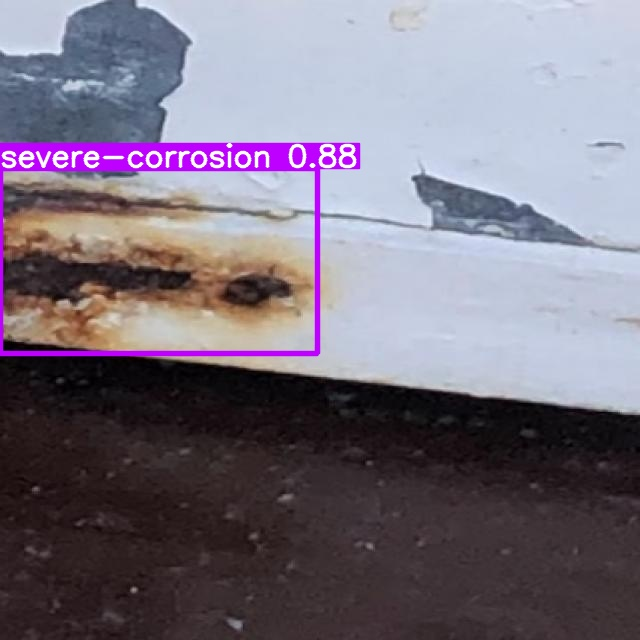

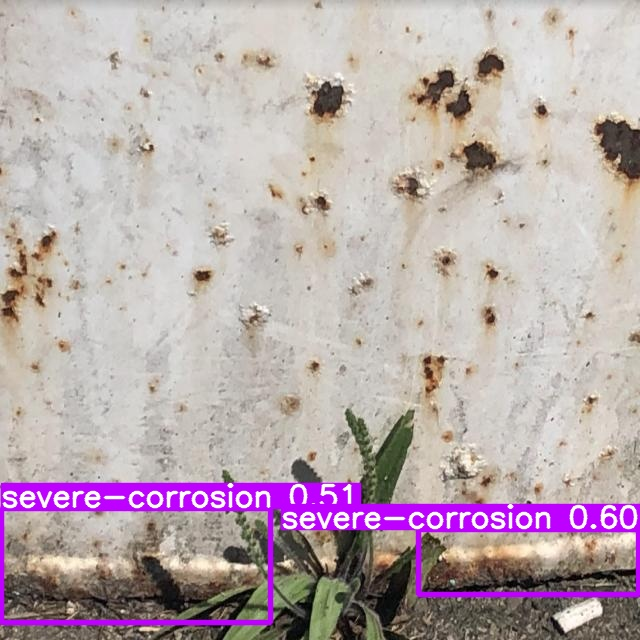

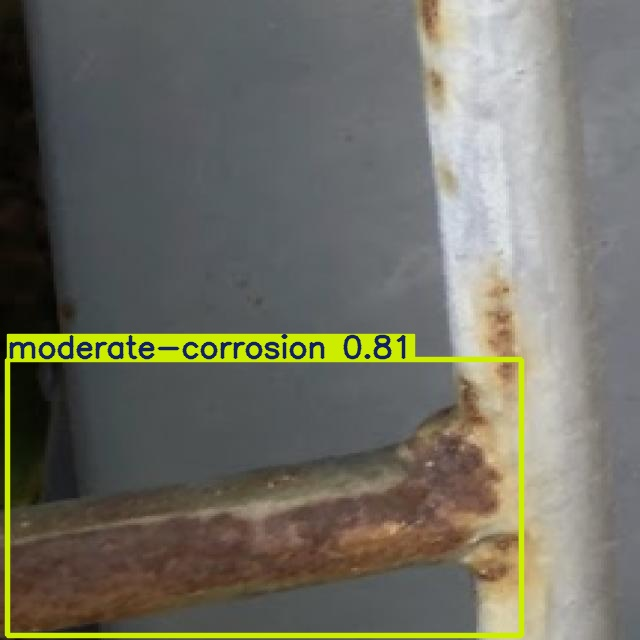

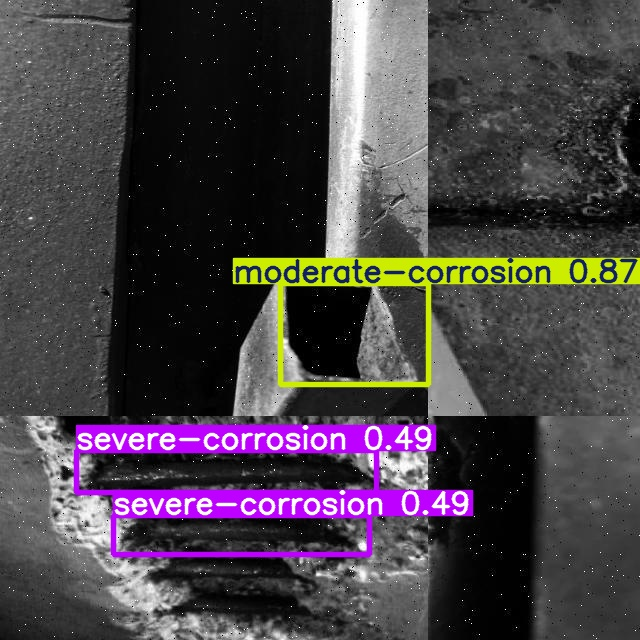

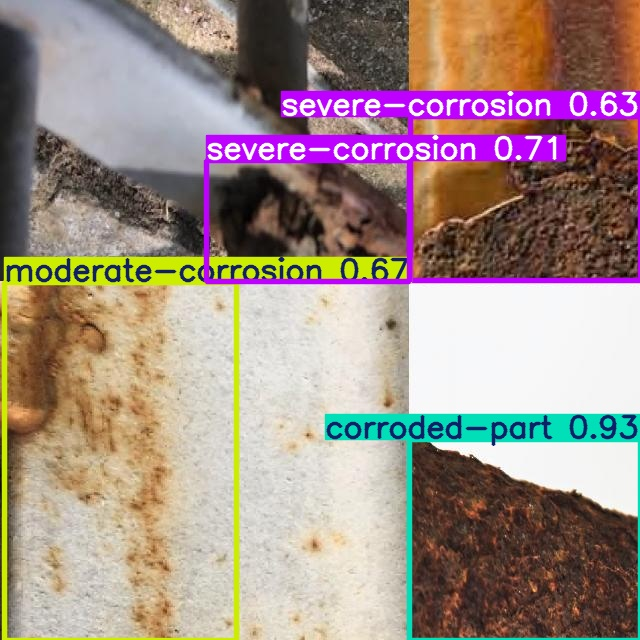

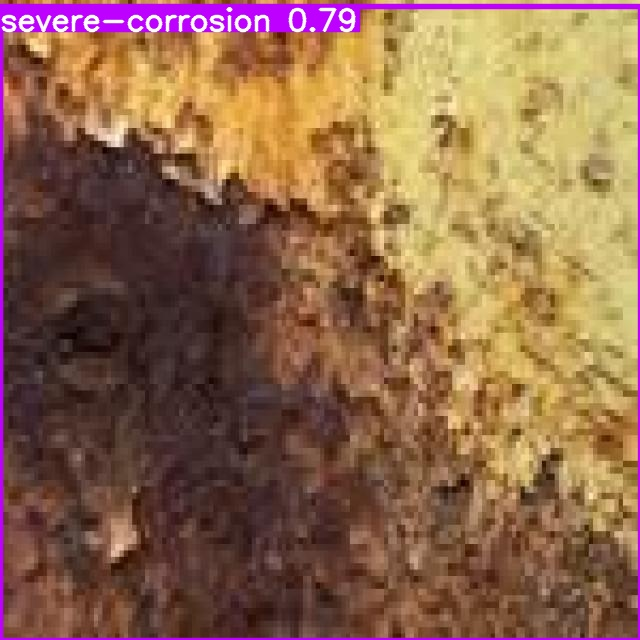

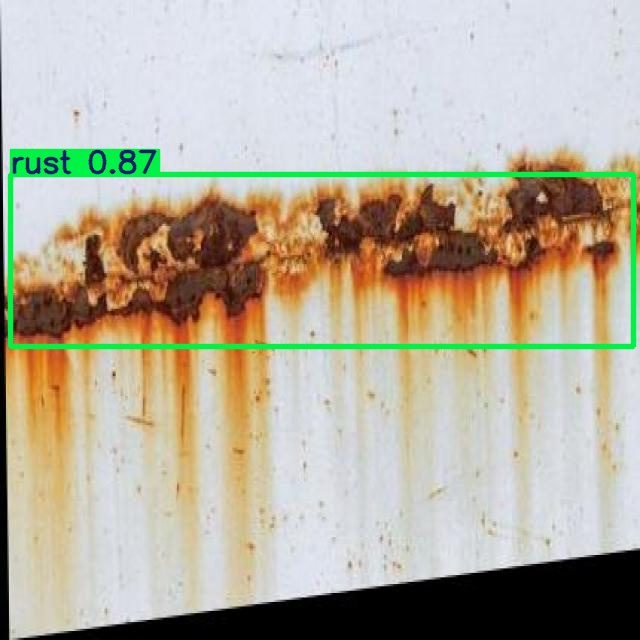

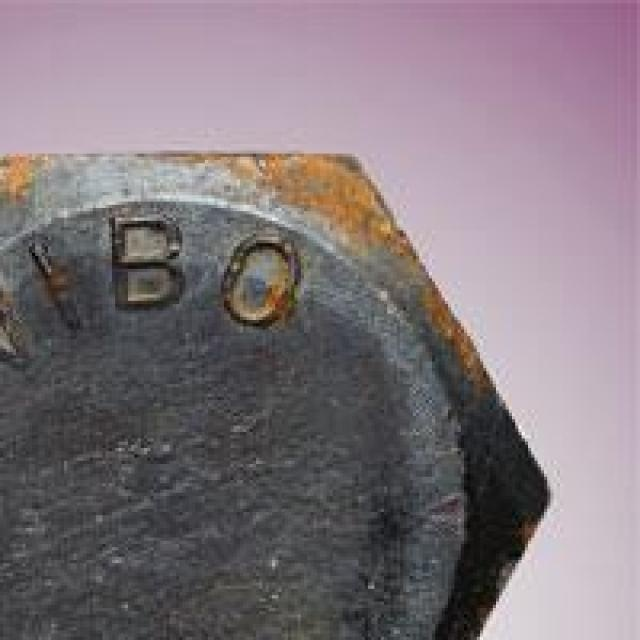

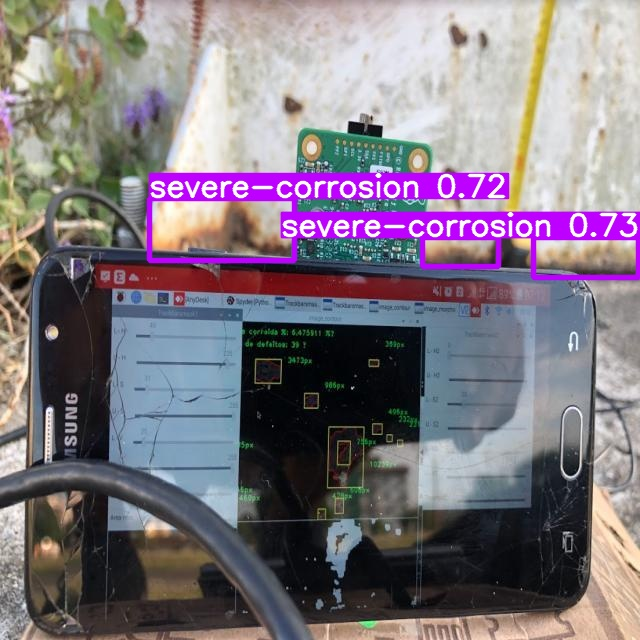

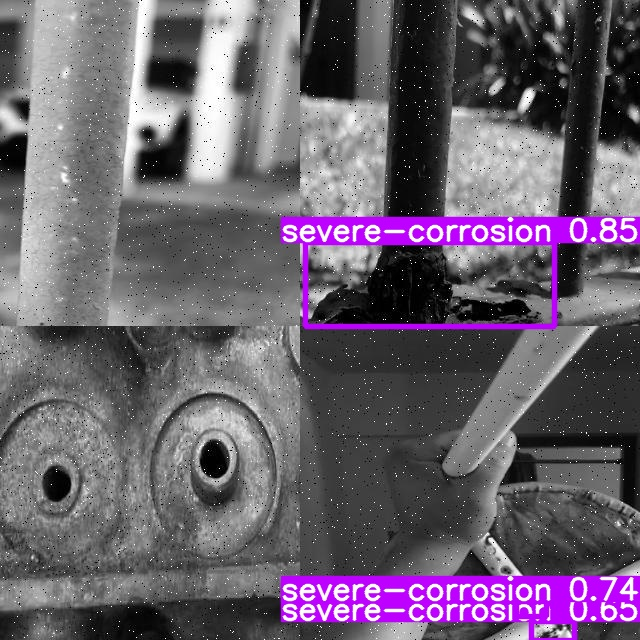

In [ ]:
import glob
from IPython.display import Image, display

for imageName in glob.glob('/content/yolov5/runs/detect/exp/*.jpg')[:10]: #assuming JPG
    display(Image(filename=imageName))

## Deploy Model on Roboflow

Once you have finished training your YOLOv5 model, you’ll have a set of trained weights ready for use. These weights will be in the `/content/yolov5/runs/train/yolov5s_results/` folder of your project. You can upload your model weights to Roboflow Deploy to use your trained weights on our infinitely scalable infrastructure.

The `.deploy()` function in the [Roboflow pip package](https://docs.roboflow.com/python) now supports uploading YOLOv5 weights.

**Before you run this code, make sure you create a new Version in the Roboflow dashboard following the instructions we covered earlier. Fill in your project name, workspace, and version number below.**

To upload model weights, add the following code to the “Inference with Custom Model” section in the aforementioned notebook:

In [ ]:
project.version(dataset.version).deploy(model_type="yolov5", model_path=f"/content/yolov5/runs/train/yolov5s_results/")

View the status of your deployment at: https://app.roboflow.com/model-examples/cash-counter-p08xm/3
Share your model with the world at: https://universe.roboflow.com/model-examples/cash-counter-p08xm/model/3


In [ ]:
#Run inference on your model on a persistant, auto-scaling, cloud API

#load model
model = project.version(dataset.version).model

#choose random test set image
import os, random
test_set_loc = dataset.location + "/test/images/"
random_test_image = random.choice(os.listdir(test_set_loc))
print("running inference on " + random_test_image)

pred = model.predict(test_set_loc + random_test_image, confidence=40, overlap=30).json()
pred

running inference on IMG_2228_jpeg_jpg.rf.5eca43a432fa01e6214b8a48b13f1823.jpg


{'predictions': [{'x': 187.0,
   'y': 366.5,
   'width': 336.0,
   'height': 275.0,
   'confidence': 0.9629614949226379,
   'class': 'ten',
   'class_id': 8,
   'detection_id': 'adcdcc63-a0cf-4006-8f51-6c2c78eb5bce',
   'image_path': '/content/yolov5/cash-counter-3/test/images/IMG_2228_jpeg_jpg.rf.5eca43a432fa01e6214b8a48b13f1823.jpg',
   'prediction_type': 'ObjectDetectionModel'}],
 'image': {'width': '640', 'height': '640'}}

# Deploy Your Model to the Edge

In addition to using the Roboflow hosted API for deployment, you can use [Roboflow Inference](https://inference.roboflow.com), an open source inference solution that has powered millions of API calls in production environments. Inference works with CPU and GPU, giving you immediate access to a range of devices, from the NVIDIA Jetson to TRT-compatible devices to ARM CPU devices.

With Roboflow Inference, you can self-host and deploy your model on-device. You can deploy applications using the [Inference Docker containers](https://inference.roboflow.com/quickstart/docker/) or the pip package.

For example, to install Inference on a device with an NVIDIA GPU, we can use:

```
docker pull roboflow/roboflow-inference-server-gpu
```

Then we can run inference via HTTP:

```python
import requests

workspace_id = ""
model_id = ""
image_url = ""
confidence = 0.75
api_key = ""
iou_threshold = 0.5

infer_payload = {
    "image": {
        "type": "url",
        "value": image_url,
    },
    "confidence": confidence,
    "iou_threshold": iou_threshold,
    "api_key": api_key,
}
res = requests.post(
    f"http://localhost:9001/{workspace_id}/{model_id}",
    json=infer_object_detection_payload,
)

predictions = res.json()
```

Above, set your Roboflow workspace ID, model ID, and API key.

- [Find your workspace and model ID](https://docs.roboflow.com/api-reference/workspace-and-project-ids?ref=blog.roboflow.com)
- [Find your API key](https://docs.roboflow.com/api-reference/authentication?ref=blog.roboflow.com#retrieve-an-api-key)

Also, set the URL of an image on which you want to run inference. This can be a local file.

_To use your YOLOv5 model commercially with Inference, you will need a Roboflow Enterprise license, through which you gain a pass-through license for using YOLOv5. An enterprise license also grants you access to features like advanced device management, multi-model containers, auto-batch inference, and more._

## 🏆 Congratulations

### Learning Resources

Roboflow has produced many resources that you may find interesting as you advance your knowledge of computer vision:

- [Roboflow Notebooks](https://github.com/roboflow/notebooks): A repository of over 20 notebooks that walk through how to train custom models with a range of model types, from YOLOv7 to SegFormer.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): Our library of videos featuring deep dives into the latest in computer vision, detailed tutorials that accompany our notebooks, and more.
- [Roboflow Discuss](https://discuss.roboflow.com/): Have a question about how to do something on Roboflow? Ask your question on our discussion forum.
- [Roboflow Models](https://roboflow.com): Learn about state-of-the-art models and their performance. Find links and tutorials to guide your learning.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.

### Connect computer vision to your project logic

[Roboflow Templates](https://roboflow.com/templates) is a public gallery of code snippets that you can use to connect computer vision to your project logic. Code snippets range from sending emails after inference to measuring object distance between detections.